In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-darkgrid")

In [4]:
np.random.seed(42)

dates = pd.date_range(start="2023-01-01", periods=24, freq="M")

df = pd.DataFrame({
    "date": dates,
    "revenue": np.random.randint(40000, 80000, 24),
    "expenses": np.random.randint(25000, 60000, 24),
    "projects_completed": np.random.randint(5, 20, 24),
    "projects_delayed": np.random.randint(0, 5, 24),
    "new_clients": np.random.randint(1, 10, 24),
    "churned_clients": np.random.randint(0, 5, 24),
    "late_payments": np.random.randint(0, 6, 24),
    "outstanding_invoices": np.random.randint(5000, 20000, 24),
    "employee_satisfaction": np.random.uniform(3.0, 5.0, 24),
    "customer_satisfaction": np.random.uniform(3.0, 5.0, 24)
})

df["profit"] = df["revenue"] - df["expenses"]
df.set_index("date", inplace=True)

df.head()

,revenue,expenses,projects_completed,projects_delayed,new_clients,churned_clients,late_payments,outstanding_invoices,employee_satisfaction,customer_satisfaction,profit
date,,,,,,,,,,,
2023-01-31,55795,25189,6,4,5,2,4,12526,3.503565,4.670605,30606
2023-02-28,40860,44118,18,4,7,0,5,13901,3.994497,3.641560,-3258
2023-03-31,78158,26899,10,1,9,1,3,10575,3.601757,3.373037,51259
2023-04-30,51284,26267,10,4,7,1,3,10530,3.569681,3.081550,25017
2023-05-31,46265,56551,14,1,9,3,3,17936,3.073774,4.181786,-10286


In [5]:
df["profit_margin"] = (df["profit"] / df["revenue"]) * 100
df["project_delay_rate"] = np.where(
    df["projects_completed"] > 0,
    (df["projects_delayed"] / df["projects_completed"]) * 100,
    0
)
df["client_churn_rate"] = np.where(
    (df["new_clients"] + df["churned_clients"]) > 0,
    (df["churned_clients"] / (df["new_clients"] + df["churned_clients"])) * 100,
    0
)
df["late_payment_rate"] = np.where(
    df["projects_completed"] > 0,
    (df["late_payments"] / df["projects_completed"]) * 100,
    0
)

df["revenue_growth"] = df["revenue"].pct_change() * 100

df.head()

,revenue,expenses,projects_completed,projects_delayed,new_clients,churned_clients,late_payments,outstanding_invoices,employee_satisfaction,customer_satisfaction,profit,profit_margin,project_delay_rate,client_churn_rate,late_payment_rate,revenue_growth
date,,,,,,,,,,,,,,,,
2023-01-31,55795,25189,6,4,5,2,4,12526,3.503565,4.670605,30606,54.854378,66.666667,28.571429,66.666667,NaN
2023-02-28,40860,44118,18,4,7,0,5,13901,3.994497,3.641560,-3258,-7.973568,22.222222,0.000000,27.777778,-26.767632
2023-03-31,78158,26899,10,1,9,1,3,10575,3.601757,3.373037,51259,65.583817,10.000000,10.000000,30.000000,91.282428
2023-04-30,51284,26267,10,4,7,1,3,10530,3.569681,3.081550,25017,48.781296,40.000000,12.500000,30.000000,-34.384196
2023-05-31,46265,56551,14,1,9,3,3,17936,3.073774,4.181786,-10286,-22.232789,7.142857,25.000000,21.428571,-9.786678


In [6]:
class HealthScorer:

    def calculate(self, row):
        score = 0

        # Financial (40)
        if row["profit_margin"] > 20:
            score += 40
        elif row["profit_margin"] > 10:
            score += 30
        elif row["profit_margin"] > 5:
            score += 20
        else:
            score += 10

        # Operational (30)
        if row["project_delay_rate"] < 10:
            score += 30
        elif row["project_delay_rate"] < 20:
            score += 20
        else:
            score += 10

        # Client (30)
        if row["client_churn_rate"] < 10:
            score += 30
        elif row["client_churn_rate"] < 20:
            score += 20
        else:
            score += 10

        return score

scorer = HealthScorer()
df["health_score"] = df.apply(scorer.calculate, axis=1)

df[["profit_margin", "project_delay_rate", "client_churn_rate", "health_score"]].head()

,profit_margin,project_delay_rate,client_churn_rate,health_score
date,,,,
2023-01-31,54.854378,66.666667,28.571429,60
2023-02-28,-7.973568,22.222222,0.000000,50
2023-03-31,65.583817,10.000000,10.000000,80
2023-04-30,48.781296,40.000000,12.500000,70
2023-05-31,-22.232789,7.142857,25.000000,50


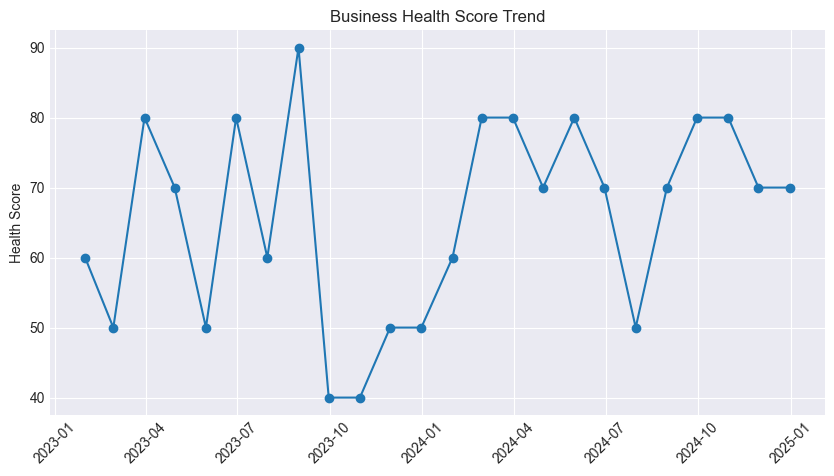

In [7]:
plt.figure(figsize=(10,5))
plt.plot(df.index, df["health_score"], marker="o")
plt.title("Business Health Score Trend")
plt.ylabel("Health Score")
plt.xticks(rotation=45)
plt.show()

In [8]:
def detect_risks(row):
    risks = []

    if row["profit_margin"] < 5:
        risks.append("Critical profit margin")

    if row["project_delay_rate"] > 30:
        risks.append("High project delays")

    if row["client_churn_rate"] > 25:
        risks.append("High client churn")

    if row["late_payment_rate"] > 30:
        risks.append("Cash flow risk")

    return risks

df["risks"] = df.apply(detect_risks, axis=1)
df[["health_score", "risks"]].tail()

,health_score,risks
date,,
2024-08-31,70,[High client churn]
2024-09-30,80,[High client churn]
2024-10-31,80,[Cash flow risk]
2024-11-30,70,[High client churn]
2024-12-31,70,[Critical profit margin]


In [9]:
features = ["revenue", "expenses", "projects_completed",
            "projects_delayed", "new_clients",
            "churned_clients", "late_payments"]

df["next_profit_margin"] = df["profit_margin"].shift(-1)
ml_data = df.dropna()

X = ml_data[features]
y = ml_data["next_profit_margin"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, predictions))
print("RMSE:", round(rmse,2))

RMSE: 32.65


In [10]:
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

importance

,feature,importance
2,projects_completed,0.255980
1,expenses,0.227227
3,projects_delayed,0.168557
0,revenue,0.119506
6,late_payments,0.088555
4,new_clients,0.082933
5,churned_clients,0.057242


In [11]:
cluster_features = ["profit_margin", "project_delay_rate", "client_churn_rate"]

scaler = StandardScaler()
scaled = scaler.fit_transform(df[cluster_features])

kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(scaled)

df.groupby("cluster")[cluster_features].mean()

,profit_margin,project_delay_rate,client_churn_rate
cluster,,,
0,-2.336160,10.085109,25.661075
1,48.417435,10.065418,35.530303
2,33.573663,60.000000,33.644481


In [12]:
def generate_insight(latest):
    return f"""
    Business Health Score: {latest.health_score}
    Profit Margin: {latest.profit_margin:.1f}%
    Delay Rate: {latest.project_delay_rate:.1f}%
    Churn Rate: {latest.client_churn_rate:.1f}%

    Key Risks: {latest.risks}
    """

latest = df.iloc[-1]
print(generate_insight(latest))


    Business Health Score: 70
    Profit Margin: -14.5%
    Delay Rate: 0.0%
    Churn Rate: 0.0%

    Key Risks: ['Critical profit margin']
    
